In [1]:
#Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

#Load data from our database
conn = sqlite3.connect("churn.db")
df = pd.read_sql("SELECT * FROM customers", conn)

#Quick check
print("Data loaded:", df.shape)
df.head()

Data loaded: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


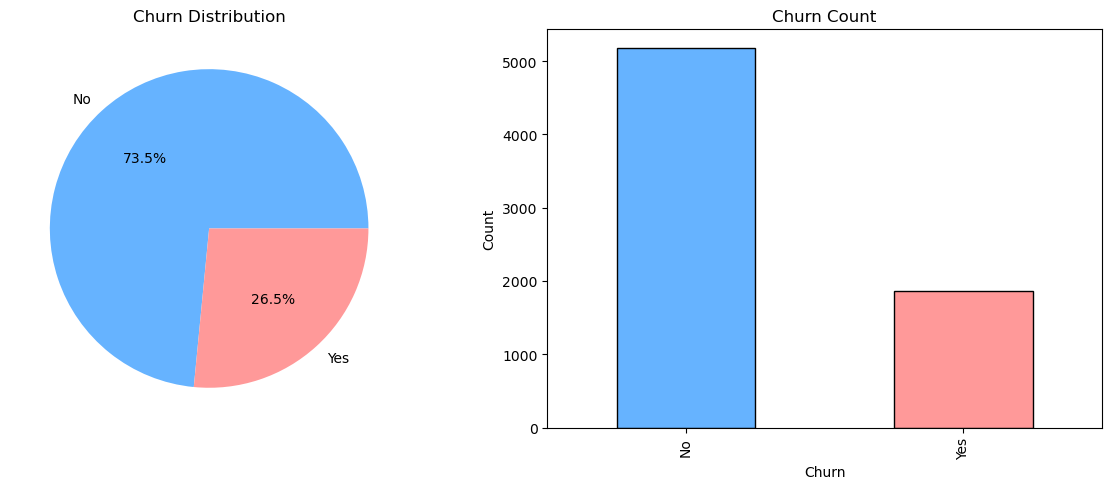

In [2]:
#Churn distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#Pie chart
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', 
                                 colors=['#66b3ff','#ff9999'],
                                 ax=axes[0])
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('')

#Bar chart
df['Churn'].value_counts().plot(kind='bar', color=['#66b3ff','#ff9999'], 
                                 ax=axes[1], edgecolor='black')
axes[1].set_title('Churn Count')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

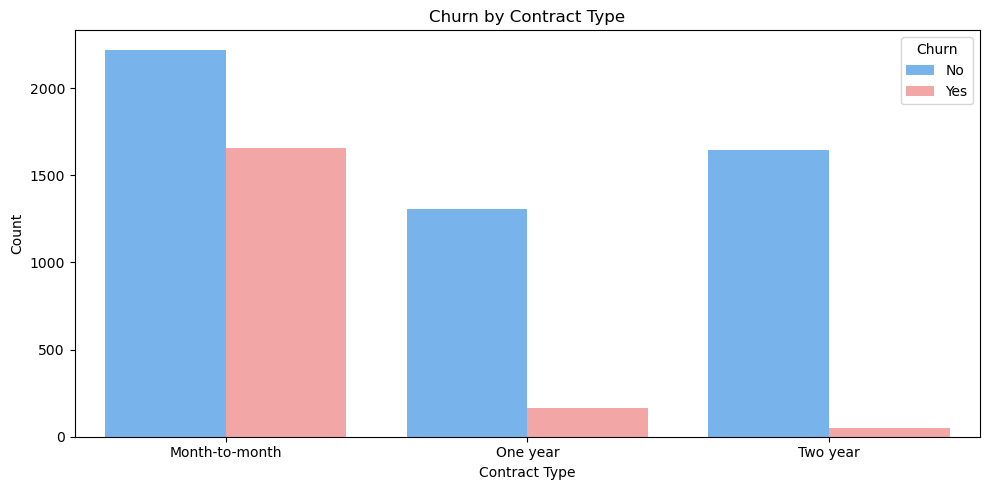

In [3]:
#Churn by contract type
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette=['#66b3ff','#ff9999'])
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

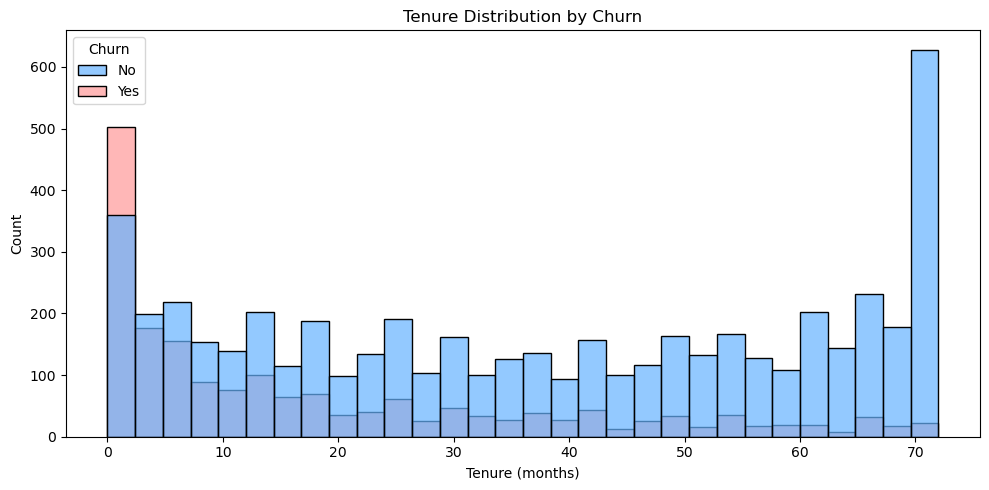

In [4]:
#Tenure distribution by churn
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, 
             palette=['#66b3ff','#ff9999'], alpha=0.7)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

C:\Users\nandi\AppData\Local\Temp\ipykernel_10592\3433688841.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges',


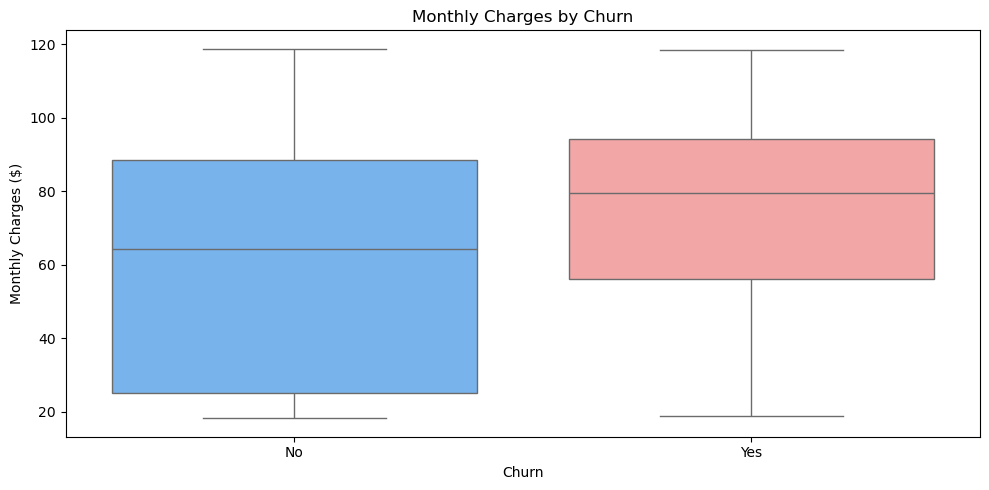

In [5]:
#Monthly charges by churn
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', 
            palette=['#66b3ff','#ff9999'])
plt.title('Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

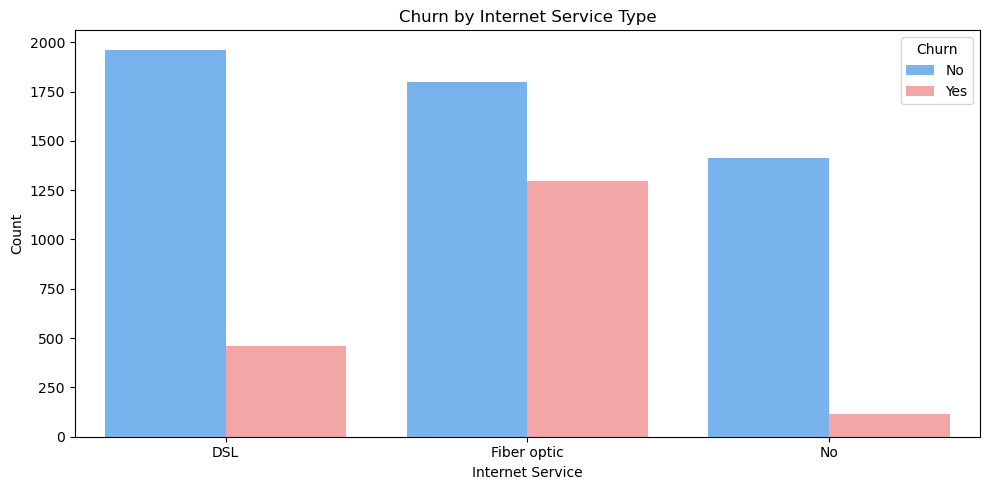

In [6]:
#Churn by internet service
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='InternetService', hue='Churn', 
              palette=['#66b3ff','#ff9999'])
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

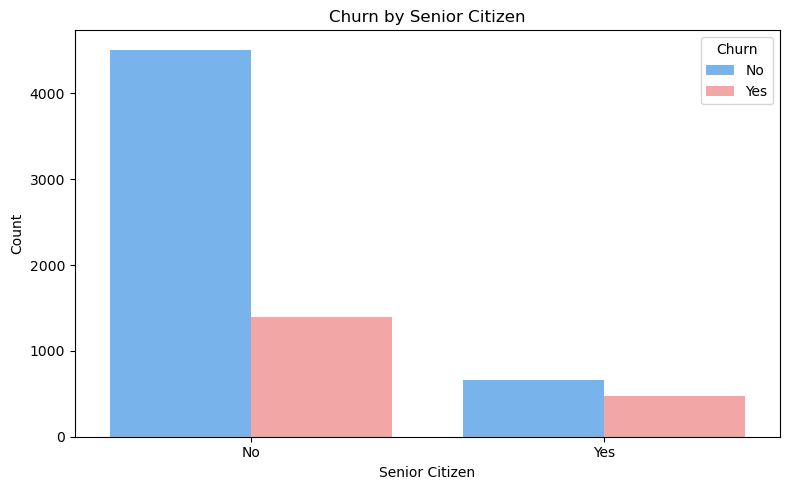

In [7]:
#Churn by Senior Citizen
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', 
              palette=['#66b3ff','#ff9999'])
plt.title('Churn by Senior Citizen')
plt.xlabel('Senior Citizen')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

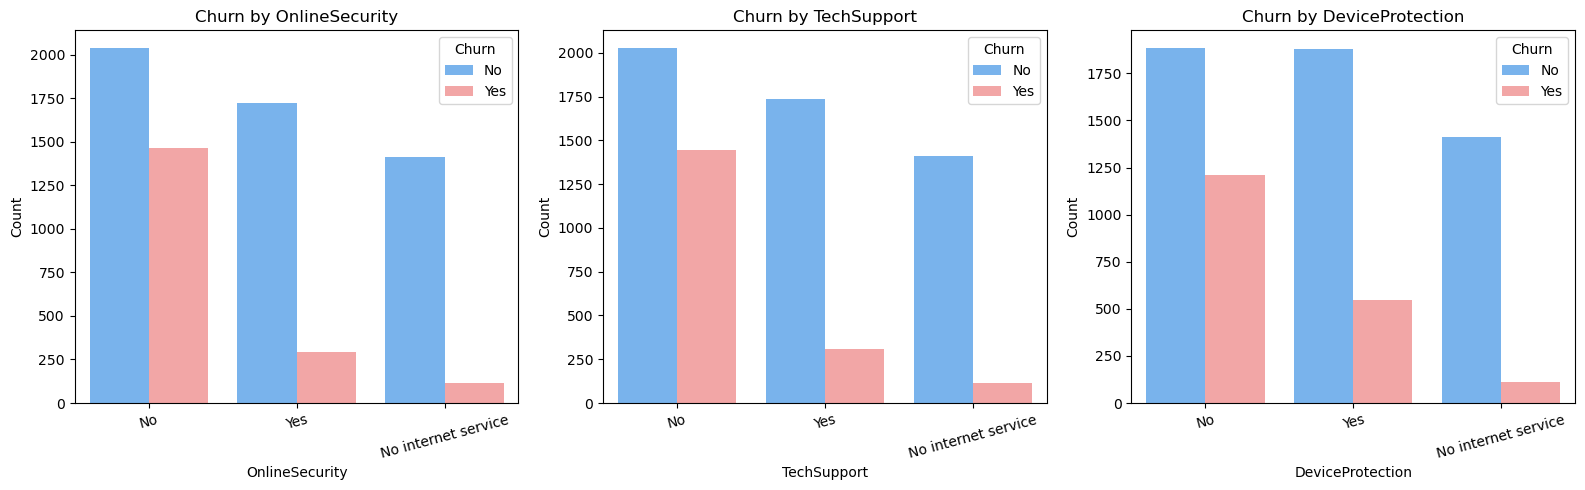

In [8]:
#Do protective services reduce churn?
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

services = ['OnlineSecurity', 'TechSupport', 'DeviceProtection']

for i, service in enumerate(services):
    sns.countplot(data=df, x=service, hue='Churn', 
                  palette=['#66b3ff','#ff9999'], ax=axes[i])
    axes[i].set_title(f'Churn by {service}')
    axes[i].set_xlabel(service)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

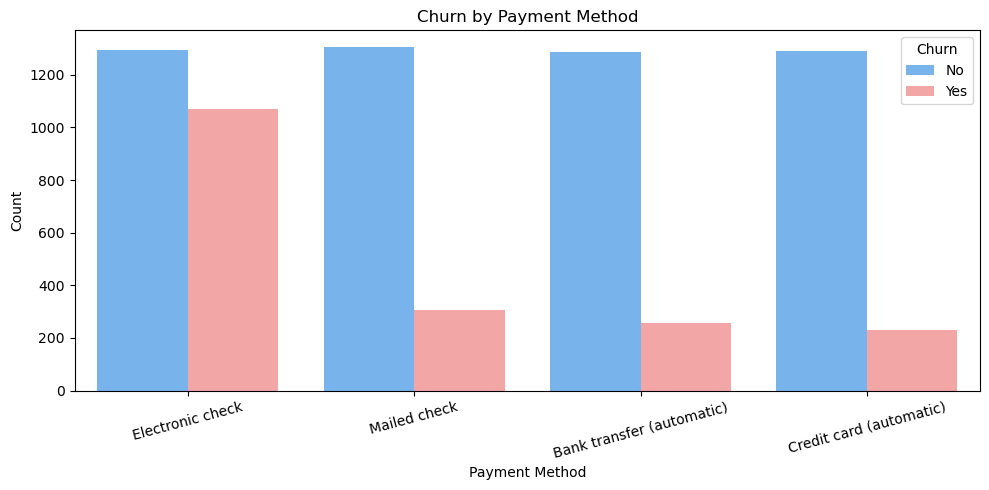

In [9]:
#Churn by Payment Method
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='PaymentMethod', hue='Churn', 
              palette=['#66b3ff','#ff9999'])
plt.title('Churn by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

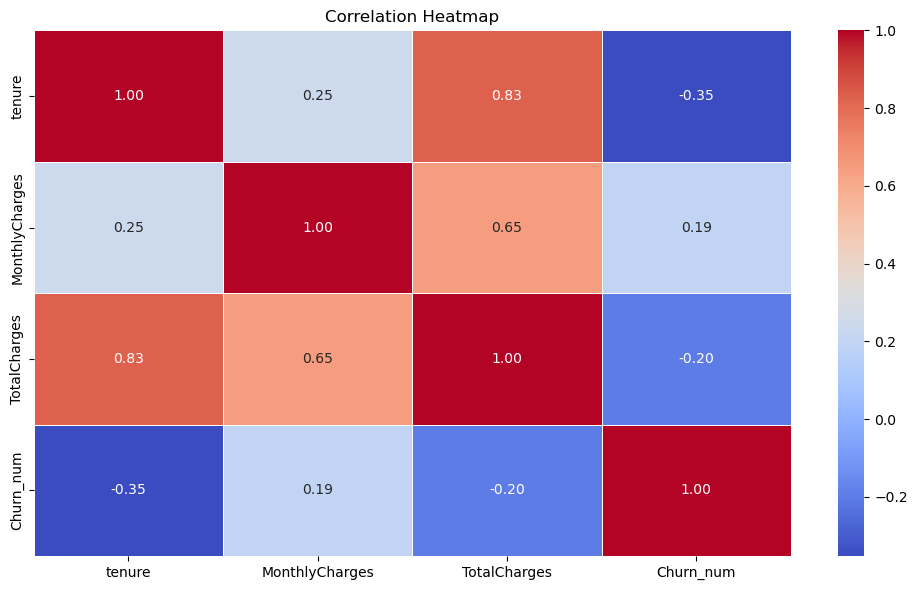

In [10]:
#Correlation heatmap
plt.figure(figsize=(10, 6))

#Convert churn to numeric for correlation
df_corr = df.copy()
df_corr['Churn_num'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

#Only numerical columns
corr = df_corr[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()